Step 1:- Load And Understand Data 

In [234]:
import pandas as pd 

In [235]:
df = pd.read_csv("C:/Users/vatsa/OneDrive/Desktop/ML WORKFLOW/student_dataset_10000_rows.csv")

In [236]:
print("Sample Row")  
print(df.head()) #Top Five Row
print(df.tail()) #Last Five Row

Sample Row
   study_hours  attendance  sleep_hours  internet_usage  \
0            7          56            8               7   
1            4          69            5               3   
2           11          60            7               6   
3            8          99            9               8   
4            5          52            8               6   

   assignments_completed  previous_score  exam_score placement_status  
0                     10              62      100.00           Placed  
1                      8              56      100.00           Placed  
2                     10              45      100.00           Placed  
3                      4              55       90.17           Placed  
4                      8              40       78.82           Placed  
      study_hours  attendance  sleep_hours  internet_usage  \
9995            2          58            9               7   
9996            7          98            6               9   
9997           1

In [237]:
print("DataSet Shape")
print(df.shape) #(Row,Column)

DataSet Shape
(10000, 8)


In [238]:
print("DataSet Info")
print(df.info()) # Data type and any null value check column wise 

DataSet Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB
None


In [239]:
print("Summary Statistic")
print(df.describe(include='all')) # describe data with maths mean std min max 

Summary Statistic
         study_hours   attendance   sleep_hours  internet_usage  \
count   10000.000000  10000.00000  10000.000000    10000.000000   
unique           NaN          NaN           NaN             NaN   
top              NaN          NaN           NaN             NaN   
freq             NaN          NaN           NaN             NaN   
mean        5.989600     69.88460      6.498500        6.062600   
std         3.163589     17.61653      1.709354        3.138163   
min         1.000000     40.00000      4.000000        1.000000   
25%         3.000000     55.00000      5.000000        3.000000   
50%         6.000000     70.00000      6.500000        6.000000   
75%         9.000000     85.00000      8.000000        9.000000   
max        11.000000    100.00000      9.000000       11.000000   

        assignments_completed  previous_score    exam_score placement_status  
count            10000.000000     10000.00000  10000.000000            10000  
unique             

In [240]:
print("------Missing Value------")
print(df.isnull().sum()) # missing value column wise sum 

------Missing Value------
study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64



Step 2:- Preprocessing (Clean Data)


In [241]:
import pandas as pd 
from sklearn.preprocessing import LabelEncoder

In [242]:
df = pd.read_csv("C:/Users/vatsa/OneDrive/Desktop/ML WORKFLOW/student_dataset_10000_rows.csv")

In [243]:
print("Missing Value in Each Column")
print(df.isnull().sum())

Missing Value in Each Column
study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64


In [244]:
le = LabelEncoder()
df['placement_status'] = le.fit_transform(df["placement_status"]) # Placed=1, Notplaced=0

print("-------After Encodding-------")
print("-------First Five Row-------")
print(df.head()) #check yes or no convert into 1 or 0
print("-------Last Five Row-------")
print(df.tail())
print("After cleaning check DataType")
print(df.dtypes) # check all data successfully convert into number 

-------After Encodding-------
-------First Five Row-------
   study_hours  attendance  sleep_hours  internet_usage  \
0            7          56            8               7   
1            4          69            5               3   
2           11          60            7               6   
3            8          99            9               8   
4            5          52            8               6   

   assignments_completed  previous_score  exam_score  placement_status  
0                     10              62      100.00                 1  
1                      8              56      100.00                 1  
2                     10              45      100.00                 1  
3                      4              55       90.17                 1  
4                      8              40       78.82                 1  
-------Last Five Row-------
      study_hours  attendance  sleep_hours  internet_usage  \
9995            2          58            9               7

In [245]:
import pandas as pd
# 1. Create a sample dataset
data = {'Student': ['Alice', 'Bob', 'Charlie'],
        'Internet': ['Yes', 'No', 'Yes']}
df = pd.DataFrame(data)
# 2. Apply get_dummies
df_encoded = pd.get_dummies(df, columns=['Internet'], dtype=int)
print(df_encoded)     # Use Of getdummies for more then 2 types of name


   Student  Internet_No  Internet_Yes
0    Alice            0             1
1      Bob            1             0
2  Charlie            0             1


Step 3:- Make Model Which Guess Student Can Placed Or Not Based On Input

In [246]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [247]:
df = pd.read_csv("C:/Users/vatsa/OneDrive/Desktop/ML WORKFLOW/student_dataset_10000_rows.csv")

In [248]:
le = LabelEncoder()
df['placement_status'] = le.fit_transform(df["placement_status"]) # placed=1, Notplaced=0

In [249]:
#Step 3 :- Feature Scaling (numeric column(big diff between number) convert to normalize(0 to 1 between)) 
features = ['study_hours','attendance','sleep_hours','internet_usage','assignments_completed','previous_score','exam_score']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])
df_scaled.head() #to see after result 
df_scaled[features].describe().round(2) # 2nd method to see mean is 0 and std is 1 then working perfectly


,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,-0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.58,-1.70,-1.46,-1.61,-1.66,-1.71,-3.99
25%,-0.95,-0.84,-0.88,-0.98,-0.83,-0.85,-0.66
50%,0.00,0.01,0.00,-0.02,0.00,0.01,0.36
75%,0.95,0.86,0.88,0.94,0.83,0.86,0.88
max,1.58,1.71,1.46,1.57,1.66,1.72,0.88


In [250]:
#Step 4:- Split data into Training and Testing 
X = df_scaled[features]  # this data want to use to make a prediction
y = df_scaled['placement_status']  # computer to guess student placed ?
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # random state give shuffel the data
X_train.head()                                            # test size is show 80% train and 20% test

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
9254,1.583850,-0.674661,-0.876691,0.298725,-0.826737,0.290764,0.506440
1561,1.583850,1.312208,-1.461737,1.254746,-1.655396,1.033530,0.882994
1670,0.319400,0.914834,0.293400,-0.338623,0.664850,1.147802,0.882994
6087,-0.945050,-0.958500,-1.461737,-0.657296,-0.661005,0.176493,-2.436918
6669,1.267738,1.596047,-1.461737,-0.657296,-0.329541,-0.452002,0.771422


In [251]:
#Step 5:- Train Model 
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [252]:
#Step 6:- Make Predictions 
y_pred = model.predict(X_test)

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       345
           1       1.00      1.00      1.00      1655

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



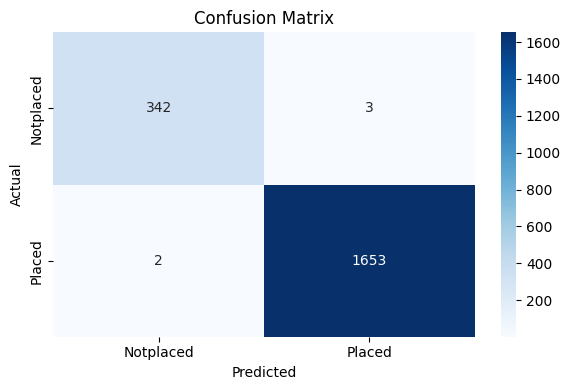

In [ ]:
#Step 7:- Model Evaluation(accuracy,precision,recall,f1-score,confusion matrics (TP,TN,FP,FN))
          # Model Performance Check
print("Classification Report") 
print(classification_report(y_test,y_pred)) # find precision recall f1-score support  

conf_matrix = confusion_matrix(y_test, y_pred) # Compares true answers with model guesses and counts the correct/incorrect results
plt.figure(figsize=(6, 4))
# Draws the grid,annot shows whole numbers, colors it blue, and adds labels
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Notplaced", "Placed"], yticklabels=["Notplaced", "Placed"])
plt.xlabel("Predicted") #x axis label
plt.ylabel("Actual")    #y axis label
plt.title("Confusion Matrix") #main title
plt.tight_layout()  #adjust spaccing complete fit 
plt.show() #final step to show image 

In [254]:
# #Stuent Give input
print("---------Predict a Student Get Placed Or Not---------")
try:
    study_hours = float(input("Enter study hours: "))
    attendance = float(input("Enter attendance: "))
    sleep_hours = float(input("Enter sleep hours: "))
    internet_usage = float(input("Enter internet_usage: "))
    assignments_completed = float(input("Enter assignments_completed: "))
    previous_score = float(input("Enter previous_score: "))
    exam_score = float(input("Enter exam_score: "))

    user_input_df = pd.DataFrame([{
        'assignments_completed': assignments_completed,
        'attendance': attendance,
        'exam_score': exam_score,
        'internet_usage': internet_usage,
        'previous_score': previous_score,
        'sleep_hours': sleep_hours,
        'study_hours': study_hours
    }])

    user_input_df = user_input_df[scaler.feature_names_in_]

    user_input_scaled = scaler.transform(user_input_df)

    prediction = model.predict(user_input_scaled)[0]

    result = "Placed" if prediction == 1 else "NotPlaced "
    print(f"Prediction Based on input: {result}")
except Exception as e:
    print("An Error Occoured", e)


---------Predict a Student Get Placed Or Not---------
Prediction Based on input: NotPlaced 


c:\Users\vatsa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
